In [1]:
import pandas as pd

FINANCIAL CORRELATIONS 

In [ ]:

finantial = pd.read_csv("data/raw/financial_impact.csv")
master = pd.read_csv("data/raw/incidents_master.csv")
market = pd.read_csv("data/raw/market_impact.csv")

merged_df = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Select numerics columns and calculate Pearson
cols = ['total_loss_usd', 'company_revenue_usd', 'employee_count', 'direct_loss_usd', 'post_incident_volatility_30d']
matrix = merged_df[cols].corr(method='pearson')

print(matrix)

                              total_loss_usd  company_revenue_usd  \
total_loss_usd                      1.000000             0.199376   
company_revenue_usd                 0.199376             1.000000   
employee_count                      0.108229             0.818477   
direct_loss_usd                     0.986984             0.200972   
post_incident_volatility_30d       -0.035490            -0.110933   

                              employee_count  direct_loss_usd  \
total_loss_usd                      0.108229         0.986984   
company_revenue_usd                 0.818477         0.200972   
employee_count                      1.000000         0.109947   
direct_loss_usd                     0.109947         1.000000   
post_incident_volatility_30d       -0.070015        -0.029612   

                              post_incident_volatility_30d  
total_loss_usd                                   -0.035490  
company_revenue_usd                              -0.110933  
employee_co

Technical impact of correlations vs Economics
--> They measure the magnitude of the attack

                              total_loss_usd  direct_loss_usd  \
total_loss_usd                      1.000000         0.986984   
direct_loss_usd                     0.986984         1.000000   
recovery_cost_usd                   0.986902         0.950880   
company_revenue_usd                 0.199376         0.200972   
data_compromised_records           -0.018118        -0.019817   
downtime_hours                     -0.073497        -0.071245   
post_incident_volatility_30d       -0.035490        -0.029612   
abnormal_return_30d                 0.092952         0.098439   

                              recovery_cost_usd  company_revenue_usd  \
total_loss_usd                         0.986902             0.199376   
direct_loss_usd                        0.950880             0.200972   
recovery_cost_usd                      1.000000             0.195739   
company_revenue_usd                    0.195739             1.000000   
data_compromised_records              -0.018413       

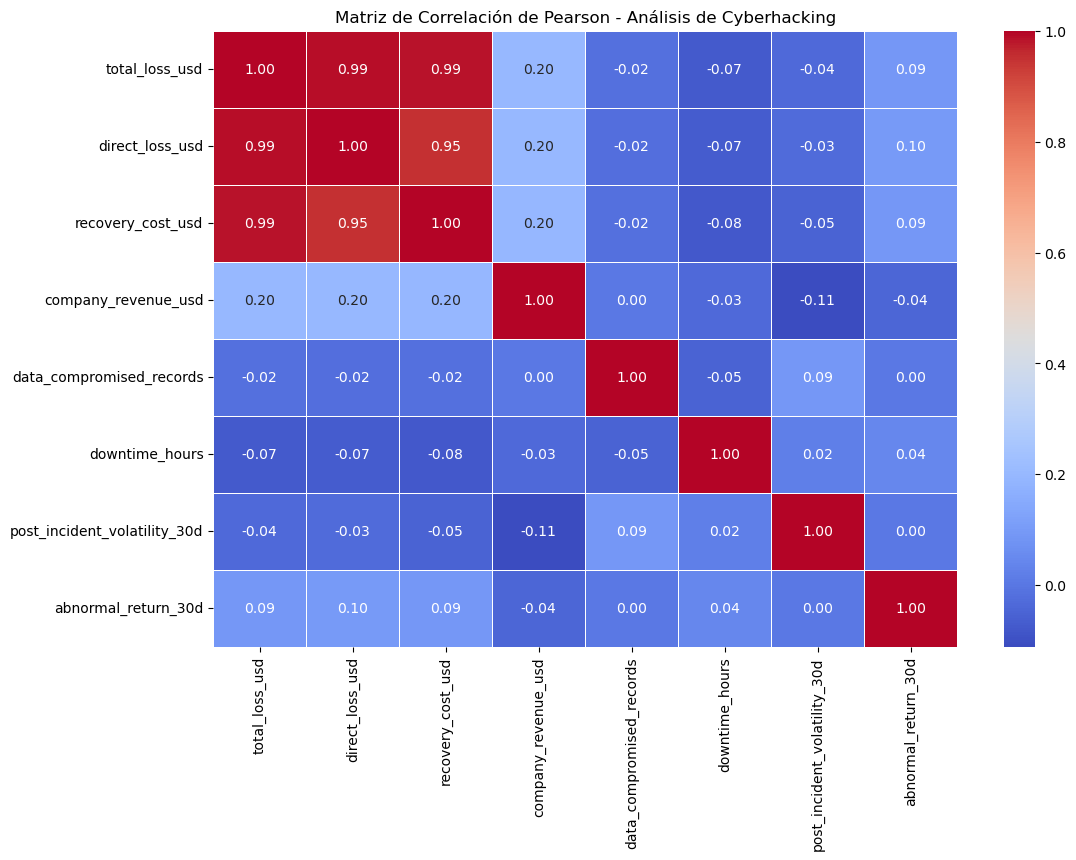

Correlaciones respecto a la Pérdida Total (Total Loss):
total_loss_usd                  1.000000
direct_loss_usd                 0.986984
recovery_cost_usd               0.986902
company_revenue_usd             0.199376
abnormal_return_30d             0.092952
data_compromised_records       -0.018118
post_incident_volatility_30d   -0.035490
downtime_hours                 -0.073497
Name: total_loss_usd, dtype: float64


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
# Usamos 'incident_id' como llave principal para cruzar la información técnica y financiera
df_combined = master.merge(finantial, on='incident_id', how='inner')
df_combined = df_combined.merge(market, on='incident_id', how='inner')

# Añadimos variables técnicas (records, downtime) y de mercado (abnormal return)
variables_interes = [
    'total_loss_usd', 
    'direct_loss_usd', 
    'recovery_cost_usd',
    'company_revenue_usd', 
    'data_compromised_records', 
    'downtime_hours',
    'post_incident_volatility_30d',
    'abnormal_return_30d'
]
# Usamos .dropna() para asegurar que el cálculo se haga sobre filas con datos completos
matrix2 = df_combined[variables_interes].corr(method='pearson')
print(matrix2)

# 5. Visualización (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(matrix2, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Pearson - Análisis de Cyberhacking")
plt.show()

# Mostrar las correlaciones más fuertes con la pérdida total
print("Correlaciones respecto a la Pérdida Total (Total Loss):")
print(matrix2['total_loss_usd'].sort_values(ascending=False))